## **Install Dependencies**

In [1]:
!pip install torchmetrics torchvision

In [2]:
!pip install torchmetrics[image]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 3.1 MB/s eta 0:00:00


In [3]:
!pip install torch-fidelity

In [4]:
# Get classifier model for inception score computation
!git clone --branch feat/classifiers https://github.com/SaraElwatany/Generative-Models.git

Cloning into 'Generative-Models'...
remote: Enumerating objects: 200, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 200 (delta 34), reused 24 (delta 3), pack-reused 67 (from 1)
Receiving objects: 100% (200/200), 246.80 MiB | 42.49 MiB/s, done.
Resolving deltas: 100% (42/42), done.


## **Import Dependencies**

In [5]:
import os
import torch
import random
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.utils import save_image
from torch.utils.data import ConcatDataset
from torchvision import datasets, transforms, models
from torchvision.transforms.functional import resize
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.fid import FrechetInceptionDistance

In [6]:
!mkdir ./checkpoints

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
print('Current Device is:', device)

Current Device is: cuda


## **Helper Functions**

In [9]:
def load_mnist_data(batch_size=32):

    """
    Function that is used to load the Mnist Dataset.
    The Mnist dataset consists of grey scale images and the images in the dataset are in the shape of (1, 28, 28).
    The function applies transformations to the images and then divides the images into batches.

    Args:
        batch_size(int, optional): The size of the batch.

    Returns:
        class_names (list): The classes in the dataset.
        trainloader (DataLoader): The batched training data.
        testloader (DataLoader): The batched test data for evaluation purposes.
    """
    

    # Image transformations; Original Img Shape: (1, 28, 28)
    transform = transforms.Compose([transforms.Resize((32, 32)),
                                    transforms.ToTensor(),
                                ])

    # Load Datasets
    train_dataset = datasets.MNIST(
                                    root="./data",
                                    train=True,
                                    download=True,
                                    transform=transform
                                )
    
    test_dataset = datasets.MNIST(
                                    root="./data",
                                    train=False,
                                    download=True,
                                    transform=transform
                                )



    # Get Dataloaders
    trainloader = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=batch_size, 
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True)


    
    
    testloader = torch.utils.data.DataLoader(test_dataset,
                                             batch_size=batch_size, 
                                             shuffle=False,
                                             num_workers=2,
                                             pin_memory=True)

    # Get classes of the test data
    class_names = test_dataset.classes

    
    return  class_names, trainloader, testloader

In [10]:
def load_flowers_data(batch_size=16, img_size=32, combine_dataset=False):

    
    """
    Function that is used to load the Oxford Flowers Dataset.
    The Flowers dataset consists of RGB images and the images in the dataset are in the shape of (3, 224, 224).
    The function applies transformations to the images and then divides the images into batches.

    Args:
        batch_size(int, optional): The size of the batch.
        img_size (int, optional): The desired height and width dimensions of the transformed images.
        combine_dataset (bool, optional): A flag that specifies whether we want the training dataset to include also the testing data or just combine the training and validation parts.

    Returns:
        class_names (list): The classes in the dataset.
        trainloader (DataLoader): The batched training data.
        testloader (DataLoader): The batched test data for evaluation purposes.
    """
    

    # Image transformations; Original Image Shape: (3, 224, 224)
    transform = transforms.Compose([transforms.Resize((img_size, img_size)),          
                                    transforms.ToTensor(), 
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    # Load Datasets
    train_dataset = datasets.Flowers102(
                                            root="./data",
                                            split="train",
                                            download=True,
                                            transform=transform
                                        )

    val_dataset = datasets.Flowers102(
                                    root="./data",
                                    split="val",
                                    download=True,
                                    transform=transform
                                  )

    
    test_dataset = datasets.Flowers102(
                                        root="./data",
                                        split="test",
                                        download=True,
                                        transform=transform
                                      )


    # Form the final training dataset
    if combine_dataset:
        train_dataset = ConcatDataset([train_dataset, val_dataset])
    else:
        train_dataset = ConcatDataset([train_dataset, val_dataset, test_dataset])


    # Get the dataloaders
    trainloader = torch.utils.data.DataLoader(train_dataset,
                                              batch_size=batch_size, 
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True)


    
    
    testloader = torch.utils.data.DataLoader(test_dataset,
                                             batch_size=batch_size, 
                                             shuffle=False,
                                             num_workers=2,
                                             pin_memory=True)

    # Get classes of the test data
    class_names = test_dataset.classes

    return  class_names, trainloader, testloader

In [11]:
def load_cifar_data(batch_size=64):

    """
    Function that is used to load the CIFAR10 Dataset.
    The CIFAR dataset consists of RGB images and the images in the dataset are in the shape of (3, 32, 32).
    The function applies transformations to the images and then divides the images into batches.

    Args:
        batch_size(int, optional): The size of the batch.

    Returns:
        class_names (list): The classes in the dataset.
        trainloader (DataLoader): The batched training data.
        testloader (DataLoader): The batched test data for evaluation purposes.
    """
    

    # Image transformations; Original Image Shape of CIFAR10: (3, 32, 32)
    transform = transforms.Compose([transforms.ToTensor(), 
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    # Load Datasets
    trainset = datasets.CIFAR10(root='./data', 
                                train=True, 
                                download=True,
                                transform=transform)

    testset = datasets.CIFAR10(root='./data', 
                               train=False, 
                               download=True,
                               transform=transform)
    

    # Get the dataloaders
    trainloader = torch.utils.data.DataLoader(trainset,
                                              batch_size=batch_size, 
                                              shuffle=True,
                                              num_workers=2,
                                              pin_memory=True)


    
    
    testloader = torch.utils.data.DataLoader(testset,
                                             batch_size=batch_size, 
                                             shuffle=False,
                                             num_workers=2,
                                             pin_memory=True)

    # Get classes of the test data
    class_names = trainset.classes

    return  class_names, trainloader, testloader

In [12]:
def show_samples(data_loader, class_names=None, n=6, binary=False):

    """
    Function that is used to display samples from a given dataset.

    Args:
        data_loader (DataLoader): The dataloader that we will show samples from.
        class_names (List, optional): The class names for each data sample.
        n (int, optional): The number of samples to display.
        binary (bool, optional): A flag that specifies whether we are displaying a black and white image or a colored one.

    Returns:
        None
    """

    # Get the first batch of the data
    images, labels = next(iter(data_loader))
    
    # Pick n random indices
    indices = random.sample(range(len(images)), n)
    
    # Select images and labels
    images = images[indices]
    labels = labels[indices]
    
    # Make a grid
    grid = torchvision.utils.make_grid(images, nrow=n)
    grid = grid.permute(1, 2, 0).cpu()  # C,H,W → H,W,C

    if not binary:
        grid = grid / 2 + 0.5  # Undo normalization [-1,1] → [0,1]

    # Form the figure
    plt.figure(figsize=(n*2, 2))
    plt.imshow(grid)
    plt.axis("off")

    # Display class labels
    if class_names is not None:
        label_names = [class_names[l] for l in labels]
        plt.title(" | ".join(label_names))

    # Display the plot
    plt.show()

In [13]:
def get_classifier_model(num_classes):
    
    """
    Initializes a ResNet-18 model pretrained on ImageNet and adapts it
    for a custom classification task.

    The final fully connected (fc) layer is replaced to match the desired
    number of output classes.

    Args:
        num_classes (int):
            Number of target classes for the classification task.

    Returns:
        torch.nn.Module:
            Modified ResNet-18 model with pretrained weights and a new
            fully connected layer of size [in_features, num_classes].

    Notes:
        - The feature extractor layers remain unchanged, while only the final
          classification layer is modified.
    """
    
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

In [14]:
def vae_loss(recon_x, x, mu, logvar, distribution_type='Gaussian', sharp=False, beta=0.5):
    
    """
    Function that is used to compute the loss of the Variational Auto Encoder (VAE), combining reconstruction loss 
    and KL divergence.

    Args:
        recon_x (torch.Tensor): The reconstructed output from the VAE. Shape (B, C, H, W) where B is batch size, C is number of channels, HxW is image size.
        x (torch.Tensor): The original input images. Same shape as recon_x.
        mu (torch.Tensor): The mean of the latent distribution predicted by the encoder. Shape (B, latent_dim).
        logvar (torch.Tensor): The log-variance of the latent distribution predicted by the encoder. Shape (B, latent_dim).
        distribution_type (str, optional): Type of reconstruction likelihood. 
            'Gaussian' for continuous outputs (use MSE or L1 loss), 
            'Bernoulli' for binary outputs (use BCE). Default is 'Gaussian'.
        sharp (bool, optional): If True and distribution_type='Gaussian', use L1 loss (less blurry) 
            for reconstruction; otherwise, use standard MSE. Default is False.
        beta (float, optional): Weighting factor for the KL divergence term. Larger beta enforces 
            stronger regularization of the latent space. Default is 0.5.

    Returns:
         torch.Tensor: Scalar tensor representing the total VAE loss: 
            loss = reconstruction_loss + beta * KL_divergence
    """

    
    # Reconstruction Loss
    if distribution_type.lower() == 'gaussian':

        if sharp:
            recon_loss = F.l1_loss(recon_x, x, reduction='sum')    
        else:
            recon_loss = F.mse_loss(recon_x, x, reduction='sum')                 # Continuous output, use MSE
        
    elif distribution_type.lower() == 'bernoulli':
        recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')        # Binary / normalized [0,1], use BCE
    else:
        raise ValueError("distribution_type must be 'Gaussian' or 'Bernoulli'")

    # KL divergence
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + beta * kl_loss

In [15]:
def train_model(model, optimizer, scheduler, train_dataloader, device=device, beta=0.5, sharp=False, epochs=100, patience=5, min_delta=0.0001, distribution='gaussian', checkpoint_dir="./checkpoints", checkpoint_path="./checkpoints/checkpoint.pt"):

    """
    Function that trains a Variational Autoencoder (VAE) model with early stopping, learning rate scheduling and checkpoint saving. 
    The function:
        - Automatically resumes training if a valid checkpoint exists at `checkpoint_path`.
        - Saves the best model checkpoint whenever validation loss improves.
        - Supports early stopping to prevent overfitting and save computation time.

    Args:

        model (torch.nn.Module): The VAE model to train.
        optimizer (torch.optim.Optimizer): Optimizer for updating model parameters.
        scheduler (torch.optim.lr_scheduler._LRScheduler): Learning rate scheduler to adjust LR.
        train_dataloader (torch.utils.data.DataLoader): DataLoader for the training dataset.
        device (torch.device, optional): Device to run the training on (CPU or GPU). Default is 'device'.
        beta (float, optional): Weight for KL divergence in VAE loss. Default is 0.5.
        sharp (bool, optional): If True, use L1 loss instead of MSE for Gaussian reconstruction. Default is False.
        epochs (int, optional): Maximum number of epochs to train. Default is 100.
        patience (int, optional): Number of epochs with no improvement before early stopping. Default is 5.
        min_delta (float, optional): Minimum change in loss to qualify as improvement for early stopping. Default is 0.0001.
        distribution (str, optional): Type of reconstruction loss, 'gaussian' or 'bernoulli'. Default is 'gaussian'.
        checkpoint_dir (str, optional): Directory to save model checkpoints. Default is "./checkpoints".
        checkpoint_path (str, optional): File path to save/load the best model checkpoint. Default is "./checkpoints/checkpoint.pt".

    Returns:
        None
    """

    
    # Early stopping parameters
    best_loss = float('inf')
    counter = 0


    # Set the model to the training mode for gradients tracking
    model.train()

    
    # Create output directory of the checkpoint if it doesn't exist
    if not os.path.exists(checkpoint_dir):
        os.mkdir(checkpoint_dir)
        

    # Load checkpoint if provided 
    if checkpoint_path is not None and os.path.exists(checkpoint_path):

        print(f"Loading checkpoint: {checkpoint_path}")

        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']

        print(f"Resuming training from epoch {start_epoch}")

    


    # Train for a number of epochs
    for epoch in range(epochs):

        # Reset total loss for each epoch
        total_loss = 0

        # Loop through each batch in the training data
        for images, _ in train_dataloader:

            
            images = images.to(device)

            # Reset the gradients to avoid accumulation
            optimizer.zero_grad()

            # Forward pass (Get reconstructed image and latent variables)
            recon, mu, logvar = model(images)

            # Compute VAE loss (reconstruction + KL divergence)
            loss = vae_loss(recon, images, mu, logvar, beta=beta, sharp=sharp, distribution_type=distribution)

            # Backpropagation: compute gradients 
            loss.backward()

            # Update model parameters using gradients
            optimizer.step()

            # Accumulate total loss
            total_loss += loss.item()

        # Get average loss per epoch
        avg_loss = total_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

        # Step scheduler
        scheduler.step(avg_loss)

        # Early Stopping Check
        if best_loss - avg_loss > min_delta:
            
            best_loss = avg_loss
            counter = 0
            
            # Save best model
            torch.save({
                            'epoch': epoch+1,
                            'model_state_dict': model.state_dict(),
                            'optimizer_state_dict': optimizer.state_dict(),
                            'scheduler_state_dict': scheduler.state_dict(),
                            'loss': avg_loss
                        }, checkpoint_path)
            
            print(f"Checkpoint saved (best model): {checkpoint_path}")
            
        else:
            counter += 1
            print(f"No improvement for {counter} epoch(s)")
    
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
            

    print("Training Finished ...")

In [16]:
def compute_is_with_classifier(model, images, device=device, splits=10):

    """
    Computes the Inception Score (IS) for a set of generated images using a given classifier.

    The Inception Score evaluates both the quality and diversity of generated images by
    measuring the KL divergence between the conditional label distribution p(y|x) and the
    marginal distribution p(y).

    Args:
        model (torch.nn.Module):
            A pretrained classifier (e.g., Inception model or custom classifier) used to
            compute class probabilities p(y|x).

        images (Iterable[Tensor]):
            Iterable of image batches with shape [B, C, H, W]. Images should be properly
            preprocessed for the classifier.

        device (torch.device, optional):
            Device to run the computation on (CPU or GPU).

        splits (int, optional):
            Number of splits used to compute IS. Splitting improves stability by computing
            the score over subsets of data and reporting mean and standard deviation.

    Returns:
        Tuple[torch.Tensor, torch.Tensor]:
            - Mean Inception Score across splits.
            - Standard deviation of the Inception Score across splits.

    Notes:
        - Higher Inception Score indicates better performance (high confidence and diversity).
        - The classifier should be trained on a dataset similar to the generated images.
        - A small epsilon (1e-10) is added to probabilities to avoid numerical instability
          in log computations.
    """

    
    model.eval()
    preds = []

    with torch.no_grad():
        
        for batch in images:
            
            batch = batch.to(device)

            outputs = model(batch)
            probs = F.softmax(outputs, dim=1)  # p(y|x)

            preds.append(probs.cpu())

    preds = torch.cat(preds, dim=0)  # [N, num_classes]

    # Split for stability
    N = preds.size(0)
    split_size = N // splits

    scores = []

    for i in range(splits):
        
        part = preds[i * split_size:(i + 1) * split_size]

        py = torch.mean(part, dim=0)  # p(y)

        kl = part * (torch.log(part + 1e-10) - torch.log(py + 1e-10))
        kl = torch.sum(kl, dim=1)

        scores.append(torch.exp(torch.mean(kl)))

    return torch.mean(torch.tensor(scores)), torch.std(torch.tensor(scores))

In [17]:
def eval_model(model, classifier_model, data_loader, batch_size=64, num_samples=500, checkpoint_path="./checkpoints/checkpoint.pt", device=device):
    
    """
    Evaluate a trained Variational Autoencoder (VAE) using FID (Fréchet Inception Distance) 
    and Inception Score (IS) metrics.

    The function generates a number of images from the VAE's latent space and compares 
    them to real images from the dataset to measure generative quality.

    Args:
        model (nn.Module): Trained VAE model.
        data_loader (DataLoader): Dataloader providing real images for comparison.
        batch_size (int): Batch size used when collecting real images.
        num_samples (int): Number of images to generate and evaluate.
        checkpoint_path (str): Path to a checkpoint file to load model weights.
        device (str or torch.device): Device to perform evaluation ('cpu' or 'cuda').

    Returns:
        fid_score (float): Fréchet Inception Distance score (lower is better).
        is_score (float): Inception Score (higher is better).
        is_std (float): Standard deviation of Inception Score across splits.
    """


    
    # Load checkpoint for VAE if provided 
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict']) 
    

    # Set model to evaluation mode
    model.eval()
    generated_images = []

    # Check if decoder ends with sigmoid to determine output range
    last_layer = list(model.decoder.children())[-1]
    use_sigmoid = isinstance(last_layer, nn.Sigmoid)

    
    with torch.no_grad():
        
        # Generate fake images
        z = torch.randn(num_samples, model.latent_dim).to(device)
        imgs = model.decode(z)
        imgs = imgs.cpu()
        
        # Undo normalization if decoder is linear (Gaussian)
        if not use_sigmoid:
            imgs = (imgs + 1) / 2
            imgs = torch.clamp(imgs, 0, 1)

        else:
            imgs = torch.clamp(imgs, 0, 1)
        
        generated_images.append(imgs)
        

    # Concatenate all generated images into a single tensor
    generated_images = torch.cat(generated_images, dim=0)
    print("Generated images shape:", generated_images.shape)

    # Collect real images from dataloader
    real_images = []
    for i, (imgs, _) in enumerate(data_loader):
        real_images.append(imgs)
        if (i + 1) * imgs.size(0) >= num_samples:
            break
            
    real_images = torch.cat(real_images, dim=0)[:num_samples]
    print("Real images shape:", real_images.shape)


    # Convert grayscale images to RGB by repeating channels
    if real_images.shape[1] == 1:
        real_images = real_images.repeat(1, 3, 1, 1)
        print("Real images reshaped to:", real_images.shape)
    if generated_images.shape[1] == 1:
        generated_images = generated_images.repeat(1, 3, 1, 1)
        print("Generated images reshaped to:", generated_images.shape)
    
    
    # Convert Images back to 0-255 range
    real_images_uint8 = (real_images * 255).to(torch.uint8).to(device)
    generated_images_uint8 = (generated_images * 255).to(torch.uint8).to(device)


    #  -------------- Compute Fréchet Inception Distance (FID)  --------------
    
    fid_metric = FrechetInceptionDistance(feature=2048).to(device)
    fid_metric.update(real_images_uint8.to(device), real=True)
    fid_metric.update(generated_images_uint8.to(device), real=False)
    fid_score = fid_metric.compute()
    print("FID score:", fid_score.item())



    #  -------------- Compute Inception Score (IS)  --------------
    
    # Apply SAME normalization used in training of classifier
    generated_images = generated_images_uint8.float() / 255.0
    generated_images = resize(generated_images, [224, 224])
    generated_images = (generated_images - torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)) / torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
                       
    # Create batches
    generated_loader = torch.utils.data.DataLoader(generated_images, batch_size=batch_size, shuffle=False)
    
    # Compute IS
    is_score, is_std = compute_is_with_classifier(classifier_model, generated_loader, device)
    print("Inception Score:", is_score.item(), "+/-", is_std.item())
    

    return fid_score.item(), is_score.item(), is_std.item()

In [18]:
def generate_samples(model, checkpoint_path, latent_dim=128, num_samples=6, save_dir="./generated_images", device=device):
    
    """
    Generate images from a trained Variational Autoencoder (VAE) by sampling random latent vectors.

    The function loads a checkpoint of a trained VAE model, samples random points in the latent space,
    decodes them into images, optionally normalizes them to [0,1] if the decoder output is linear,
    and saves the images to disk.

    Args:
        model (nn.Module): Trained VAE model.
        checkpoint_path (str): Path to the model checkpoint (.pt or .pth) to load weights from.
        latent_dim (int, optional): Dimensionality of the VAE latent space. Defaults to 128.
        num_samples (int, optional): Number of images to generate. Defaults to 6.
        save_dir (str, optional): Directory to save the generated images. Defaults to "./generated_images".
        device (str or torch.device, optional): Device to perform computations on ('cpu' or 'cuda'). Defaults to device.

    Returns:
        torch.Tensor: Tensor of generated images of shape (num_samples, C, H, W) in [0,1] range.
    """

    #
    os.makedirs(save_dir, exist_ok=True)

    
    # Load checkpoint 
    if checkpoint_path is not None and os.path.exists(checkpoint_path):
        print(f"Loading checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict']) 
    

    #
    model.eval()


    # Check if decoder ends with sigmoid
    last_layer = list(model.decoder.children())[-1]
    use_sigmoid = isinstance(last_layer, nn.Sigmoid)



    # Sample random latent vectors
    with torch.no_grad():
        
        z = torch.randn(num_samples, model.latent_dim).to(device)
        generated_images = model.decode(z)  # output in [0,1] if decoder ends with Sigmoid
        generated_images = generated_images.cpu()  # move to CPU

        # Undo normalization if decoder is linear (Gaussian) 
        if not use_sigmoid: 
            generated_images = (generated_images + 1) / 2 
            generated_images = torch.clamp(generated_images, 0, 1)
        else:
            generated_images = torch.clamp(generated_images, 0, 1)
            

    
    
    for i, img in enumerate(generated_images):
        save_path = os.path.join(save_dir, f"generated_{i+1}.png")
        save_image(img, save_path)        # save_image expects a tensor in [C,H,W]
        print(f"Saved image: {save_path}")
            

    return generated_images

## **Model Architecture**

In [19]:
class VAE(nn.Module):
    
    def __init__(self, input_channels=3, img_size=128, latent_dim=128, distribution_type='Gaussian'):
        
        super(VAE, self).__init__()

        # Get image size
        self.img_size = img_size

        # Get number of image channels
        self.input_channels = input_channels
        
        # 
        self.distribution = distribution_type

        # Get the latent space dimension
        self.latent_dim = latent_dim

        # Define the encoder layers
        self.encoder = nn.Sequential(
                                        nn.Conv2d(self.input_channels, 32, kernel_size=4, stride=2, padding=1),  # 32 x img_size/2 x img_size/2 
                                        nn.ReLU(),
            
                                        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 64 x img_size/4 x img_size/4 
                                        nn.ReLU(),
            
                                        nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 128 x img_size/8 x img_size/8
                                        nn.ReLU(),
                                    )
        
        # Define the mean and variance linear layers
        self.fc_mu = nn.Linear((128 * self.img_size * self.img_size) // 64, latent_dim)
        self.fc_logvar = nn.Linear((128 * self.img_size * self.img_size) // 64, latent_dim)

        # Define the decoding layer to reshape the latent space to input to the decoder
        self.fc_decode = nn.Linear(latent_dim, (128 * self.img_size * self.img_size) // 64)

        # Define the decoder layers
        self.decoder = nn.Sequential(
                                        nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 64 x img_size/4 x img_size/4 
                                        nn.ReLU(),
            
                                        nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 32 x img_size/2 x img_size/2 
                                        nn.ReLU(),
            
                                        nn.ConvTranspose2d(32, self.input_channels, kernel_size=4, stride=2, padding=1),   # 3 x img_size x img_size
                                        nn.Sigmoid() if self.input_channels == 1 else nn.Identity()    # sigmoid output in [0,1]
                                    )
        

    
    def encode(self, x):

        """
        Encodes the input image into latent space parameters.
    
        Args:
            x (torch.Tensor): Input image tensor of shape 
                [batch_size, channels, height, width].
    
        Returns:
            mu (torch.Tensor): Mean of the latent Gaussian distribution 
                of shape [batch_size, latent_dim].
            logvar (torch.Tensor): Log variance of the latent Gaussian 
                distribution of shape [batch_size, latent_dim].
    
        Notes:
            - The encoder outputs a feature map which is flattened using:
                h.view(h.size(0), -1)
            - h.size(0) corresponds to the batch size.
            - Flattening keeps the batch dimension unchanged while collapsing
        """
        
        h = self.encoder(x)
        h = h.view(h.size(0), -1)  # flatten
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        return mu, logvar

    
    
    
    def reparameterize(self, mu, logvar):

        """
        Applies the reparameterization trick to sample from the latent space.

        Args:
            mu (torch.Tensor): Mean of the latent Gaussian distribution 
                of shape [batch_size, latent_dim].
            logvar (torch.Tensor): Log variance of the latent Gaussian 
                distribution of shape [batch_size, latent_dim].
    
        Returns:
            z (torch.Tensor): Sampled latent vector of shape 
                [batch_size, latent_dim].
    
        Notes:
            - std is computed as: std = exp(0.5 * logvar)
            - eps is random noise sampled from N(0, 1) with the same shape as std.
            - The output is computed as:
                  z = mu + eps * std
            - This trick allows gradients to flow through mu and logvar during training.
        """
        
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        
        return mu + eps * std
        

    
    
    def decode(self, z):

        """
        Decodes a latent vector back into the image space.

        Args:
            z (torch.Tensor): Latent vector of shape 
                [batch_size, latent_dim].
    
        Returns:
            x_recon (torch.Tensor): Reconstructed image tensor of shape 
                [batch_size, channels, height, width].
    
        Notes:
            - The latent vector is first projected using a fully connected layer.
            - It is then reshaped into a feature map using:
                  h.view(batch_size, channels, height, width)
            - The decoder upsamples this feature map back to the original image size.
        """
        
        h = self.fc_decode(z)
        h = h.view(-1, 128, self.img_size // 8, self.img_size // 8)
        x_recon = self.decoder(h)
        
        return x_recon


    

    
    def forward(self, x):

        """
        Performs the full forward pass of the Variational Autoencoder (VAE).

        Args:
            x (torch.Tensor): Input image tensor of shape 
                [batch_size, channels, height, width].
    
        Returns:
            x_recon (torch.Tensor): Reconstructed image tensor of the same shape as input.
            mu (torch.Tensor): Mean of the latent Gaussian distribution 
                of shape [batch_size, latent_dim].
            logvar (torch.Tensor): Log variance of the latent Gaussian distribution 
                of shape [batch_size, latent_dim].
    
        Notes:
            - The forward pass consists of three main steps:
                1. Encoding: The input is mapped to latent distribution parameters (mu, logvar).
                2. Reparameterization: A latent vector z is sampled using mu and logvar.
                3. Decoding: The latent vector z is used to reconstruct the input image.
            - Both mu and logvar are returned to compute the KL divergence loss during training.
        """
        
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        
        return x_recon, mu, logvar

## **Load Training & Testing Datasets**

In [20]:
# Set Dataset configs
IMG_SIZE = 32
DATASET_INDEX = 2

In [21]:
Datasets = ["mnist", "cifar10", "oxford_flowers"]

In [22]:
chosen_dataset = Datasets[DATASET_INDEX]

In [25]:
# Create DataLoaders
if chosen_dataset == "mnist":
    IMG_CHANNELS = 1
    BINARY_FLAG = True
    class_names, train_dataloader, test_dataloader = load_mnist_data(batch_size=32)
elif chosen_dataset == "cifar10":
    IMG_CHANNELS = 3
    BINARY_FLAG = False
    class_names, train_dataloader, test_dataloader = load_cifar_data(batch_size=32)
elif chosen_dataset == "oxford_flowers":
    IMG_CHANNELS = 3
    BINARY_FLAG = False
    class_names, train_dataloader, test_dataloader = load_flowers_data(batch_size=16, img_size=32, combine_dataset=True)

In [24]:
print('Number of Training Batches formed:', len(train_dataloader))
print('Number of Testing Batches formed:', len(test_dataloader))

Number of Training Batches formed: 128
Number of Testing Batches formed: 385


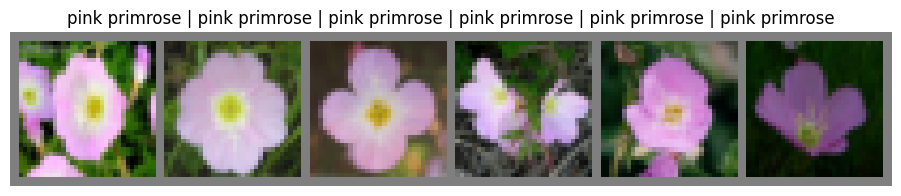

In [26]:
# Show some testing samples
show_samples(test_dataloader, class_names, binary=BINARY_FLAG)

## **Building The Model**

In [27]:
# Get number of output classes for prediction
num_classes = len(class_names)

# Specify the classifier's checkpoint based on dataset name
dataset_mapping = {"mnist": "./Generative-Models/classifiers/mnist_best_classifier.pth",
                   "cifar10": "./Generative-Models/classifiers/cifar10_best_classifier.pth",
                   "oxford_flowers": "./Generative-Models/classifiers/flowers_best_classifier.pth"
                  }

# Load the classifier model to be used in the Inception score calculation
classifier_model = get_classifier_model(num_classes).to(device)
classifier_checkpoint = torch.load(dataset_mapping[chosen_dataset], map_location=device)
classifier_model.load_state_dict(classifier_checkpoint)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s] 


<All keys matched successfully>

In [28]:
model = VAE(input_channels=IMG_CHANNELS, img_size=IMG_SIZE, latent_dim=128).to(device)

In [29]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [30]:
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
#lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

## **Training The Model**

In [236]:
train_model(model, optimizer, lr_scheduler, train_dataloader, epochs=500, beta=5, sharp=False, distribution='gaussian', checkpoint_path='./checkpoints/checkpoint.pt', device=device)

Loading checkpoint: ./checkpoints/checkpoint.pt
Resuming training from epoch 3
Epoch 1, Loss: 146.4699
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 2, Loss: 145.1996
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 3, Loss: 144.9985
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 4, Loss: 144.8139
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 5, Loss: 144.7081
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 6, Loss: 144.0619
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 7, Loss: 143.9184
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 8, Loss: 143.8276
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 9, Loss: 143.8020
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 10, Loss: 143.4683
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 11, Loss: 143.3637
Checkpoint saved (best model): ./checkpoints/checkpoint.pt
Epoch 

## **Evaluating The Model Performance**

In [94]:
# Evaluate the model using the FID and Inception scores
metrics = eval_model(model, classifier_model=classifier_model, data_loader=test_dataloader, batch_size=32, num_samples=100, device=device)

Loading checkpoint: ./my_vae_checkpoints_main/checkpoints/flowers_beta_5.pt
Generated images shape: torch.Size([100, 3, 32, 32])
Real images shape: torch.Size([100, 3, 32, 32])
FID score: 319.6781005859375
Inception Score: 1.1719648838043213 +/- 0.028371209278702736



## **Generation**

In [242]:
# Generate samples of images
generated_imgs = generate_samples(model, num_samples=100, checkpoint_path="./checkpoints/checkpoint.pt")

Loading checkpoint: ./checkpoints/checkpoint.pt
Saved image: ./generated_images/generated_1.png
Saved image: ./generated_images/generated_2.png
Saved image: ./generated_images/generated_3.png
Saved image: ./generated_images/generated_4.png
Saved image: ./generated_images/generated_5.png
Saved image: ./generated_images/generated_6.png
Saved image: ./generated_images/generated_7.png
Saved image: ./generated_images/generated_8.png
Saved image: ./generated_images/generated_9.png
Saved image: ./generated_images/generated_10.png
Saved image: ./generated_images/generated_11.png
Saved image: ./generated_images/generated_12.png
Saved image: ./generated_images/generated_13.png
Saved image: ./generated_images/generated_14.png
Saved image: ./generated_images/generated_15.png
Saved image: ./generated_images/generated_16.png
Saved image: ./generated_images/generated_17.png
Saved image: ./generated_images/generated_18.png
Saved image: ./generated_images/generated_19.png
Saved image: ./generated_image